# ResNet50 + Contrastive Regularization (Fine-tune)
This notebook fine-tunes ResNet50 with a contrastive regularizer.

Sections:
- 1) Setup and Imports
- 2) Dataset and Dataloaders
- 3) Model and Loss
- 4) Training Loop
- 5) Evaluation and Plots

Tips: Set `lambda_contrastive=0.0` to run CE-only baselines.


In [1]:
# 1) Setup and Imports
# Basic utilities and HDF5 visualization helper
import h5py
from dl_utils.utils.utils import viz_h5_structure

In [10]:
with h5py.File('../../datasets/imagenet_v5_rot_10k_fix_vector_a100_0.h5', 'r') as f:
    viz_h5_structure(f)

'Group': imagenet
  'Dataset': data; Shape: (10013, 256, 256, 3); dtype: uint8
  'Dataset': labels; Shape: (10013,); dtype: uint8
  'Dataset': primitive_uc_vector_a; Shape: (10013, 2); dtype: int32
  'Dataset': primitive_uc_vector_b; Shape: (10013, 2); dtype: int32
  'Dataset': rotation_angle; Shape: (10013,); dtype: uint8
  'Dataset': shape; Shape: (10013,); dtype: uint8
  'Dataset': translation_start_point; Shape: (10013, 2); dtype: int32
  'Dataset': translation_uc_vector_a; Shape: (10013, 2); dtype: int32
  'Dataset': translation_uc_vector_b; Shape: (10013, 2); dtype: int32


In [1]:
# Additional imports for training and visualization
# Model builder, trainer, and the contrastive-regularized loss wrapper
import os, numpy as np, torch, torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms

from dl_utils.utils.dataset import hdf5_dataset, split_train_valid, viz_dataloader
from dl_utils.utils.utils import list_to_dict
from dl_utils.training.build_model import resnet50_
from dl_utils.training.trainer import Trainer, accuracy
from dl_utils.training.contrastive_loss import ContrastiveRegularizedLoss
import wandb

# Symmetry classes and helper to map label -> index
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)
n_classes = len(symmetry_classes)

/mnt/scratch/home/yichen/anaconda3/envs/symmetry/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 2) Config: dataset paths, training hyperparameters, and contrastive settings
task_name = "ResNet50-CR"
ds_path_info = {
    'imagenet': '../../datasets/imagenet_v5_rot_10k_fix_vector_a100_0.h5',
    'atom': '../../datasets/atom_v5_rot_1m_fix_vector.h5',
    'noise': '../../datasets/noise_v5_rot_1m_fix_vector.h5',
    'viz_dataloader': False,  # set True to visualize few batches
}

training_specs = {
    'ds_size': 10_000,              # number of samples for each auxiliary set (noise/atom) and for imagenet subset build
    'batch_size': 256,
    'num_workers': 8,
    'learning_rate': 1e-3,
    'training_image_count': 2_000_000,  # for epochs calc: images_processed / len(train_ds)
    'validation_times': 10,
    'efficient_print': True,
    'model_path': '../../models/ResNet50/',
    'folder_name': 'default',        # or a custom name
    'device_ids': [8, 9],               # [0,1] if using DP
    'epoch_start': 0,
}

# W&B (optional)
wandb_specs = {}   # or populate as in your existing runs

# Contrastive settings
metadata_key = 'primitive_uc_vector_a'    # HDF5 key under 'imagenet' folder that stores per-sample metadata
# lambda_contrastive = 0
lambda_contrastive = 0.02
pos_threshold = 0.2
neg_threshold = 0.7
margin = 0.5
metadata_distance = 'cosine'     # 'l2' or 'cosine'
feature_layer = 'avgpool'    # resnet50_ has 'avgpool'
feature_norm = True


/mnt/scratch/home/yichen/anaconda3/envs/symmetry/lib/python3.11/site-packages/m3util/viz/layout.py:255: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(wspace=wspace, hspace=hspace)


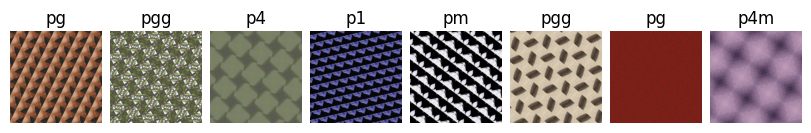

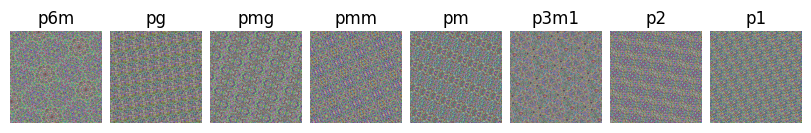

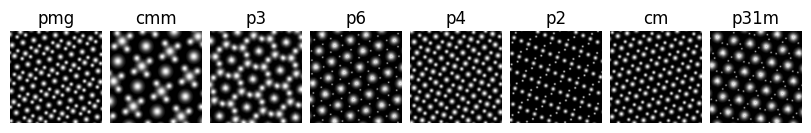

In [3]:
# 2) Dataset and Dataloaders
# Imagenet with metadata for training
imagenet_all = hdf5_dataset(
    ds_path_info['imagenet'],
    folder='imagenet',
    transform=transforms.ToTensor(),
    metadata_keys=metadata_key,
)
ratio = training_specs['ds_size'] * (1/0.8) / len(imagenet_all)
imagenet_sub, _ = split_train_valid(imagenet_all, ratio, seed=42)
train_ds, valid_ds = split_train_valid(imagenet_sub, 0.8, seed=42)

train_dl = DataLoader(train_ds, batch_size=training_specs['batch_size'], shuffle=True,  num_workers=training_specs['num_workers'])
valid_dl = DataLoader(valid_ds, batch_size=training_specs['batch_size'], shuffle=False, num_workers=training_specs['num_workers'])
viz_dataloader(valid_dl, label_converter=label_converter, title='imagenet - valid')

# Noise CV
noise_ds_all = hdf5_dataset(ds_path_info['noise'], folder='noise', transform=transforms.ToTensor())
ratio_noise = np.min((training_specs['ds_size'] / len(noise_ds_all), 1))
noise_ds, _ = split_train_valid(noise_ds_all, ratio_noise, seed=42)
noise_dl = DataLoader(noise_ds, batch_size=training_specs['batch_size'], shuffle=False, num_workers=training_specs['num_workers'])
viz_dataloader(noise_dl, label_converter=label_converter, title='noise - valid')

# Atom CV
atom_ds_all = hdf5_dataset(ds_path_info['atom'], folder='atom', transform=transforms.ToTensor())
ratio_atom = np.min((training_specs['ds_size'] / len(atom_ds_all), 1))
atom_ds, _ = split_train_valid(atom_ds_all, ratio_atom, seed=42)
atom_dl = DataLoader(atom_ds, batch_size=training_specs['batch_size'], shuffle=False, num_workers=training_specs['num_workers'])
viz_dataloader(atom_dl, label_converter=label_converter, title='atom - valid')

In [4]:
# 3) Model: ResNet50 backbone (with optional DataParallel)
device = torch.device(f"cuda:{training_specs['device_ids'][0]}" if torch.cuda.is_available() else "cpu")

model = resnet50_(in_channels=3, n_classes=n_classes, dropout=0.5, weights=None)
if len(training_specs['device_ids']) > 1:
    model = torch.nn.DataParallel(model, device_ids=training_specs['device_ids'])
model = model.to(device)

In [5]:
# 3b) Loss, optimizer, scheduler, and metrics
lr = training_specs['learning_rate']
epoch_start = training_specs.get('epoch_start', 0)
epochs = training_specs['training_image_count'] // len(train_ds) - epoch_start
valid_per_epochs = int(np.max((1, epochs / training_specs['validation_times'])))
early_stopping_patience = np.max((5, valid_per_epochs + 2))
efficient_print = training_specs['efficient_print']

base_ce = nn.CrossEntropyLoss()
loss_func = ContrastiveRegularizedLoss(
    base_criterion=base_ce,
    model=model,
    lambda_contrastive=lambda_contrastive,
    feature_layer=feature_layer,
    pos_threshold=pos_threshold,
    neg_threshold=neg_threshold,
    margin=margin,
    feature_norm=feature_norm,
    metadata_key=metadata_key,
    metadata_distance=metadata_distance,
)

optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, epochs=epochs, max_lr=lr, steps_per_epoch=len(train_dl)
)
metrics = [accuracy]


In [6]:
# 3c) Weights & Biases setup (optional)
NAME = task_name + '-dstaset_size=' + str(training_specs['ds_size'])
if wandb_specs:
    wandb.login()
    wandb.init(
        project=wandb_specs['project'], entity=wandb_specs['entity'],
        name=NAME, id=NAME, group=wandb_specs['group'],
        save_code=wandb_specs['save_code'], config=wandb_specs['config'], resume=wandb_specs['resume']
    )
    training_specs['wandb_record'] = True
else:
    training_specs['wandb_record'] = False

# 4) Training Loop and Validation
Runs the Trainer and logs per-epoch metrics including base CE and contrastive components (if enabled).


In [7]:
folder_name = training_specs['folder_name'] if training_specs['folder_name'] != 'default' else NAME
model_dir = os.path.join(training_specs['model_path'], folder_name)
os.makedirs(model_dir, exist_ok=True)

trainer = Trainer(
    model=model,
    loss_func=loss_func,
    optimizer=optimizer,
    metrics=metrics,
    scheduler=scheduler,
    device=device,
    save_per_epochs=valid_per_epochs,
    model_path=model_dir + '/',
    early_stopping_patience=early_stopping_patience,
    efficient_print=efficient_print,
)

history = trainer.train(
    train_dl=train_dl,
    epochs=epochs,
    epoch_start=epoch_start,
    valid_per_epochs=valid_per_epochs,
    valid_dl_list=[valid_dl, noise_dl, atom_dl],
    valid_dl_names=['', 'noise', 'atom'],
    wandb_record=training_specs['wandb_record'],
)

[0, 24, 48, 72, 96, 120, 144, 168, 192, 216, 240]
Epoch: 1/249


Train: 100%|██████████| 32/32 [00:25<00:00,  1.26it/s]


train_loss: 2.8404, train_accuracy: 5.79%


Valid: 100%|██████████| 8/8 [00:07<00:00,  1.06it/s]


valid_loss: 2.8332, valid_accuracy: 6.49%
Model saved at epoch 0
Saved new best model at epoch 0 with valid dataset


...

valid_loss: 2.8332, valid_accuracy: 6.49%


Valid: 100%|██████████| 40/40 [00:05<00:00,  7.50it/s]


noise_loss: 2.8332, noise_accuracy: 5.67%


Valid: 100%|██████████| 40/40 [00:05<00:00,  7.65it/s]

atom_loss: 2.8332, atom_accuracy: 5.90%


In [ ]:
%load_ext autoreload
%autoreload 2
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
from dl_utils.utils.dataset import viz_dataloader, split_train_valid, hdf5_dataset
from dl_utils.training.build_model import resnet50_, fpn_resnet50_classification
from dl_utils.training.trainer import Trainer, accuracy
from dl_utils.packed_functions import benchmark_task_contrastive

ds_path_info = {'imagenet': '../../datasets/imagenet_v5_rot_10k_fix_vector_a100_0.h5',
                'noise': '../../datasets/noise_v5_rot_1m_fix_vector.h5',
                'atom': '../../datasets/atom_v5_rot_1m_fix_vector.h5',
                'viz_dataloader': False}

training_specs = {'batch_size': 1200,
                  'num_workers': 8,
                  'device_ids': [8, 9],
                  'shuffle': True,
                  'learning_rate': 1e-3,
                  'epochs': 1000,
                  'validation_times': 200,
                  'training_image_count': 10000000*20, # 20 epochs of 10 million images of full imagenet dataset
                  'efficient_print': True,
                  'model_path': '../../models/ResNet50/',
}

config = {'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
          'optimizer': 'Adam',
          'scheduler': 'OneCycleLR'}
    
# wandb_specs = {'config': config,
#                 'project': 'Understanding-Experimental-Images-by-Identifying-Symmetries-with-Deep-Learning',
#                 'entity': 'yig319',
#                 'group': 'benchmark',
#                 'save_code': True,
#                 'resume': 'allow'}

model = resnet50_(in_channels=3, n_classes=17)
task_name = '09042025-ResNet50-contrastive_reg'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
def benchmark_task_contrastive(
    task_name,
    model,
    training_specs,
    ds_path_info,
    wandb_specs={},
    # Contrastive settings
    metadata_key=None,               # HDF5 key containing per-sample metadata
    metadata_distance='l2',          # 'l2' or 'cosine'
    lambda_contrastive=0.1,
    pos_threshold=0.1,
    neg_threshold=0.5,
    margin=1.0,
    feature_layer='avgpool',
    feature_norm=True,
):
    """
    Mirrors benchmark_task, but uses ContrastiveRegularizedLoss that aligns feature distances
    to metadata distances for the training set. Uses the same loaders, logging, and saving.
    Provide the HDF5 `metadata_key` available under the same folder as data/labels.
    """
    # symmetry classes
    symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
    label_converter = list_to_dict(symmetry_classes)
    # imagenet with optional metadata for contrastive reg
    imagenet_ds = hdf5_dataset(
        ds_path_info['imagenet'],
        folder='imagenet',
        transform=transforms.ToTensor(),
        metadata_keys=metadata_key,
    )
    ratio = training_specs['ds_size'] * (1/0.8) / len(imagenet_ds)
    imagenet_ds, _ = split_train_valid(imagenet_ds, ratio, seed=42)
    train_ds, valid_ds = split_train_valid(imagenet_ds, 0.8, seed=42)
    train_dl = DataLoader(train_ds, batch_size=training_specs['batch_size'], shuffle=True, num_workers=training_specs['num_workers'])
    # For validation, metadata is not needed; we can omit to reduce overhead
    valid_dl = DataLoader(valid_ds, batch_size=training_specs['batch_size'], shuffle=False, num_workers=training_specs['num_workers'])
    # noise
    noise_ds = hdf5_dataset(ds_path_info['noise'], folder='noise', transform=transforms.ToTensor())
    ratio = np.min((training_specs['ds_size'] / len(noise_ds), 1))
    noise_ds, rest_ds = split_train_valid(noise_ds, ratio, seed=42)
    noise_dl = DataLoader(noise_ds, batch_size=training_specs['batch_size'], shuffle=False, num_workers=training_specs['num_workers'])
    # atom
    atom_ds = hdf5_dataset(ds_path_info['atom'], folder='atom', transform=transforms.ToTensor())
    ratio = np.min((training_specs['ds_size'] / len(atom_ds), 1))
    atom_ds, rest_ds = split_train_valid(atom_ds, ratio, seed=42)
    atom_dl = DataLoader(atom_ds, batch_size=training_specs['batch_size'], shuffle=False, num_workers=training_specs['num_workers'])
    # visualization
    if ds_path_info['viz_dataloader']:
        viz_dataloader(train_dl, label_converter=label_converter, title='imagenet - train')
        viz_dataloader(valid_dl, label_converter=label_converter, title='imagenet - valid')
        viz_dataloader(noise_dl, label_converter=label_converter, title='noise - cv')
        viz_dataloader(atom_dl, label_converter=label_converter, title='atom - cv')
    # model
    device = torch.device('cuda:{}'.format(training_specs['device_ids'][0]))
    if len(training_specs['device_ids']) > 1:
        model = torch.nn.DataParallel(model, device_ids=training_specs['device_ids'])
    else:
        model = model.to(device)
    # wandb
    NAME = task_name + '-dstaset_size=' + str(training_specs['ds_size'])
    if wandb_specs != {}:
        wandb.login()
        wandb.init(project=wandb_specs['project'], entity=wandb_specs['entity'], name=NAME, id=NAME, group=wandb_specs['group'], save_code=wandb_specs['save_code'], config=wandb_specs['config'], resume=wandb_specs['resume'])
        training_specs['wandb_record'] = True
    else:
        training_specs['wandb_record'] = False
    # training setup (same scheduling as benchmark_task)
    lr = training_specs['learning_rate']
    epoch_start = training_specs.get('epoch_start', 0)
    epochs = training_specs['training_image_count'] // len(train_ds) - epoch_start
    valid_per_epochs = int(np.max((1, epochs / training_specs['validation_times'])))
    early_stopping_patience = np.max((5, valid_per_epochs + 2))
    efficient_print = training_specs['efficient_print']
    # Base criterion + contrastive regularizer
    base_ce = nn.CrossEntropyLoss()
    loss_func = ContrastiveRegularizedLoss(
        base_criterion=base_ce,
        model=model,
        lambda_contrastive=lambda_contrastive,
        feature_layer=feature_layer,
        pos_threshold=pos_threshold,
        neg_threshold=neg_threshold,
        margin=margin,
        feature_norm=feature_norm,
        metadata_key=metadata_key,
        metadata_distance=metadata_distance,
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, steps_per_epoch=len(train_dl))
    metrics = [accuracy]
    folder_name = training_specs['folder_name'] if training_specs['folder_name'] != 'default' else NAME
    trainer = Trainer(
        model=model,
        loss_func=loss_func,
        optimizer=optimizer,
        metrics=metrics,
        scheduler=scheduler,
        device=device,
        save_per_epochs=valid_per_epochs,
        model_path=training_specs['model_path'] + folder_name + '/',
        early_stopping_patience=early_stopping_patience,
        efficient_print=efficient_print,
    )
    history = trainer.train(
        train_dl=train_dl,
        epochs=epochs,
        epoch_start=epoch_start,
        valid_per_epochs=valid_per_epochs,
        valid_dl_list=[valid_dl, noise_dl, atom_dl],
        valid_dl_names=['', 'noise', 'atom'],
        wandb_record=training_specs['wandb_record'],
    )
    wandb.finish()
    print(history)
    trainer.plot_training_metrics()
    return model, history
    

In [11]:
training_specs['ds_size'] = 10000000
training_specs['folder_name'] = task_name + '-10k'
model, history = benchmark_task_contrastive(task_name, model, training_specs=training_specs, ds_path_info=ds_path_info, 
                                            metadata_key='primitive_uc_vector_a')

[0, 124, 248, 372, 496, 620, 744, 868, 992, 1116, 1240, 1364, 1488, 1612, 1736, 1860, 1984, 2108, 2232, 2356, 2480, 2604, 2728, 2852, 2976, 3100, 3224, 3348, 3472, 3596, 3720, 3844, 3968, 4092, 4216, 4340, 4464, 4588, 4712, 4836, 4960, 5084, 5208, 5332, 5456, 5580, 5704, 5828, 5952, 6076, 6200, 6324, 6448, 6572, 6696, 6820, 6944, 7068, 7192, 7316, 7440, 7564, 7688, 7812, 7936, 8060, 8184, 8308, 8432, 8556, 8680, 8804, 8928, 9052, 9176, 9300, 9424, 9548, 9672, 9796, 9920, 10044, 10168, 10292, 10416, 10540, 10664, 10788, 10912, 11036, 11160, 11284, 11408, 11532, 11656, 11780, 11904, 12028, 12152, 12276, 12400, 12524, 12648, 12772, 12896, 13020, 13144, 13268, 13392, 13516, 13640, 13764, 13888, 14012, 14136, 14260, 14384, 14508, 14632, 14756, 14880, 15004, 15128, 15252, 15376, 15500, 15624, 15748, 15872, 15996, 16120, 16244, 16368, 16492, 16616, 16740, 16864, 16988, 17112, 17236, 17360, 17484, 17608, 17732, 17856, 17980, 18104, 18228, 18352, 18476, 18600, 18724, 18848, 18972, 19096, 19220,

Train:   0%|          | 0/7 [00:27<?, ?it/s]


IndexError: The shape of the mask [1200, 1200] at index 0 does not match the shape of the indexed tensor [600, 600] at index 0

In [1]:
%load_ext autoreload
%autoreload 2
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import h5py
import wandb
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
from m3util.viz.layout import layout_fig

from dl_utils.analysis.confusion_matrix import show_multiple_cm, confusion_matrix
from dl_utils.utils.utils import list_to_dict, sort_tasks_by_size, find_last_epoch_file
from dl_utils.utils.dataset import viz_dataloader, split_train_valid, hdf5_dataset
from dl_utils.training.build_model import resnet50_, xcit_small, fpn_resnet50_classification, densenet161_
from dl_utils.training.trainer import Trainer, accuracy

/mnt/scratch/home/yichen/anaconda3/envs/symmetry/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ds_path_info = {'imagenet': '../../datasets/imagenet_v5_rot_10m_fix_vector.h5',
                'noise': '../../datasets/noise_v5_rot_1m_fix_vector.h5',
                'atom': '../../datasets/atom_v5_rot_1m_fix_vector.h5',
                'viz_dataloader': False}

training_specs = {'batch_size': 3000, 
                  'num_workers': 8, 
                  'device_ids': [0, 1], 
                  'shuffle': True,
                  'learning_rate': 1e-3,
                  'epochs': 1000,
                  'validation_times': 200,
                  'training_image_count': 10000000*20, # 20 epochs of 10 million images of full imagenet dataset
                  'efficient_print': True,
                  'model_path': '../../models/ResNet50/',
}

config = {'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
          'optimizer': 'Adam',
          'scheduler': 'OneCycleLR'}
    
# wandb_specs = {'config': config,
#                 'project': 'Understanding-Experimental-Images-by-Identifying-Symmetries-with-Deep-Learning',
#                 'entity': 'yig319',
#                 'group': 'benchmark',
#                 'save_code': True,
                # 'resume': 'allow'}

model = resnet50_(in_channels=3, n_classes=17)
task_name = '03132025-ResNet50-benchmark'

In [ ]:
model.load_state_dict(torch.load('../../models/ResNet50/09112024-resnet50-dataset_v5_size-10m/model_epoch_20.pth', weights_only=True, map_location=torch.device('cpu')))

training_specs['epoch_start'] = 15
training_specs['ds_size'] = 10000000
training_specs['folder_name'] = '09112024-resnet50-dataset_v5_size-10m'

# model, history = benchmark_task(task_name, model, training_specs=training_specs, ds_path_info=ds_path_info, wandb_specs=wandb_specs)

In [ ]:
    # symmetry classes
    symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
    label_converter = list_to_dict(symmetry_classes)

    # imagenet
    imagenet_ds = hdf5_dataset(ds_path_info['imagenet'], folder='imagenet', transform=transforms.ToTensor())
    ratio = training_specs['ds_size'] * (1/0.8) / len(imagenet_ds)
    imagenet_ds, _ = split_train_valid(imagenet_ds, ratio, seed=42)
    train_ds, valid_ds = split_train_valid(imagenet_ds, 0.8, seed=42) 
    train_dl = DataLoader(train_ds, batch_size=training_specs['batch_size'], shuffle=True, num_workers=training_specs['num_workers'])
    valid_dl = DataLoader(valid_ds, batch_size=training_specs['batch_size'], shuffle=False, num_workers=training_specs['num_workers'])

    # noise
    noise_ds = hdf5_dataset(ds_path_info['noise'], folder='noise', transform=transforms.ToTensor())
    ratio = np.min((training_specs['ds_size'] / len(noise_ds), 1)) # avoid larger than 1
    noise_ds, rest_ds = split_train_valid(noise_ds, ratio, seed=42)
    noise_dl = DataLoader(noise_ds, batch_size=training_specs['batch_size'], shuffle=False, num_workers=training_specs['num_workers'])
    
    # atom
    atom_ds = hdf5_dataset(ds_path_info['atom'], folder='atom', transform=transforms.ToTensor())
    ratio = np.min((training_specs['ds_size'] / len(atom_ds), 1)) # avoid larger than 1
    atom_ds, rest_ds = split_train_valid(atom_ds, ratio, seed=42)
    atom_dl = DataLoader(atom_ds, batch_size=training_specs['batch_size'], shuffle=False, num_workers=training_specs['num_workers'])
    
    # visualization
    if ds_path_info['viz_dataloader']:
        viz_dataloader(train_dl, label_converter=label_converter, title='imagenet - train')
        viz_dataloader(valid_dl, label_converter=label_converter, title='imagenet - valid')
        viz_dataloader(noise_dl, label_converter=label_converter, title='noise - cv')
        viz_dataloader(atom_dl, label_converter=label_converter, title='atom - cv')

    # model 
    device = torch.device('cuda:{}'.format(training_specs['device_ids'][0]))
    if len(training_specs['device_ids']) > 1:
        model = torch.nn.DataParallel(model, device_ids=training_specs['device_ids'])
    else:
        model = model.to(device)
        
    # wandb
    NAME = task_name + '-dstaset_size=' + str(training_specs['ds_size'])
    if wandb_specs != {}:
        wandb.login()
        wandb.init(project=wandb_specs['project'], entity=wandb_specs['entity'], name=NAME, id=NAME, group=wandb_specs['group'], save_code=wandb_specs['save_code'], config=wandb_specs['config'], resume=wandb_specs['resume'])
        training_specs['wandb_record'] = True
    else:
        training_specs['wandb_record'] = False
        
    # training
    lr = training_specs['learning_rate']
    if 'epoch_start' in training_specs:
        epoch_start = training_specs['epoch_start']
    else:
        epoch_start = 0
    epochs = training_specs['training_image_count'] // len(train_ds) - epoch_start # training epochs based on the number of images in the dataset 
    valid_per_epochs = int(np.max((1, epochs / training_specs['validation_times']))) # validation times based on the number of epochs, and at least 1
    early_stopping_patience = np.max((5, valid_per_epochs+2)) # early stopping patience based on the number of validation times, and at least 2
    efficient_print = training_specs['efficient_print']
    loss_func = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, steps_per_epoch=len(train_dl))
    metrics = [accuracy]  # You can add more metrics if needed
    if training_specs['folder_name'] == 'default':
        folder_name = NAME
    else:
        folder_name = training_specs['folder_name']
    
    trainer = Trainer(model=model, loss_func=loss_func, optimizer=optimizer, metrics=metrics, scheduler=scheduler, device=device, save_per_epochs=valid_per_epochs, model_path=training_specs['model_path']+folder_name+'/', early_stopping_patience=early_stopping_patience, efficient_print=efficient_print) # 

    history = trainer.train(train_dl=train_dl, epochs=epochs, epoch_start=epoch_start, valid_per_epochs=valid_per_epochs, valid_dl_list=[valid_dl, noise_dl, atom_dl], valid_dl_names=['', 'noise', 'atom'], wandb_record=training_specs['wandb_record'])
    wandb.finish()
    
    print(history)
    trainer.plot_training_metrics()
    

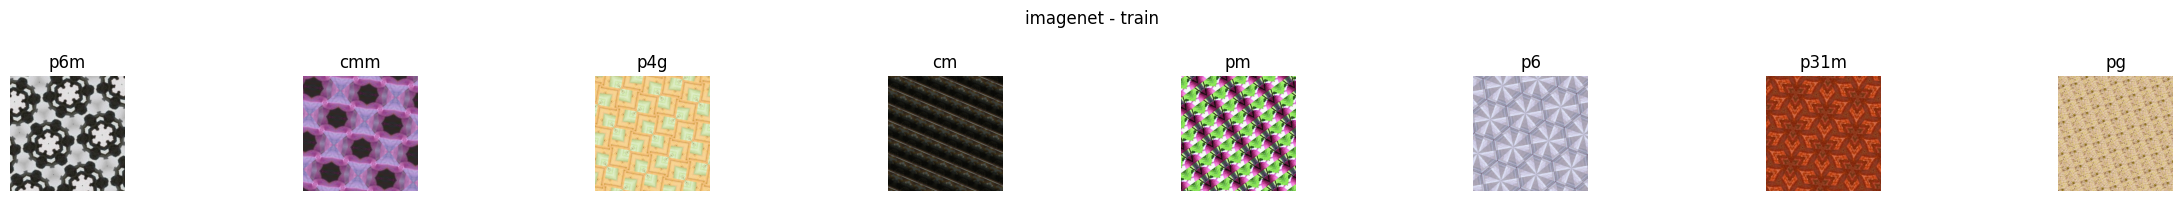

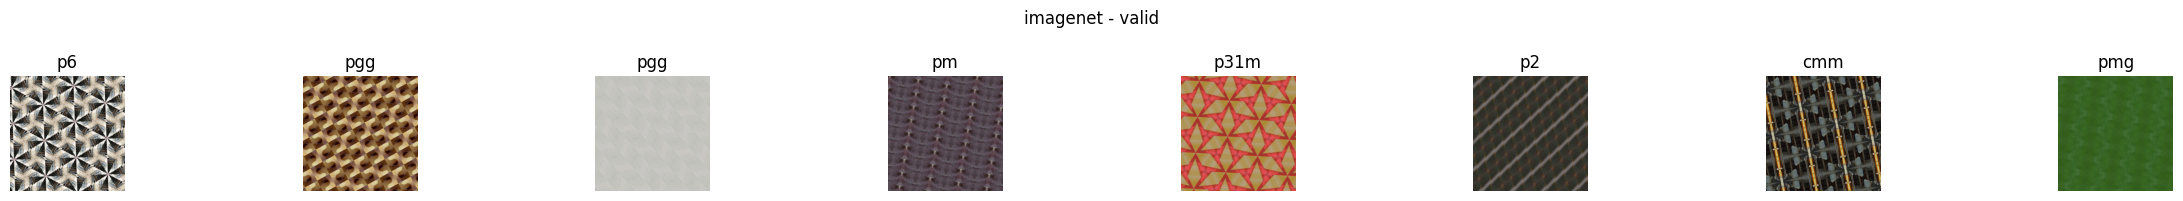

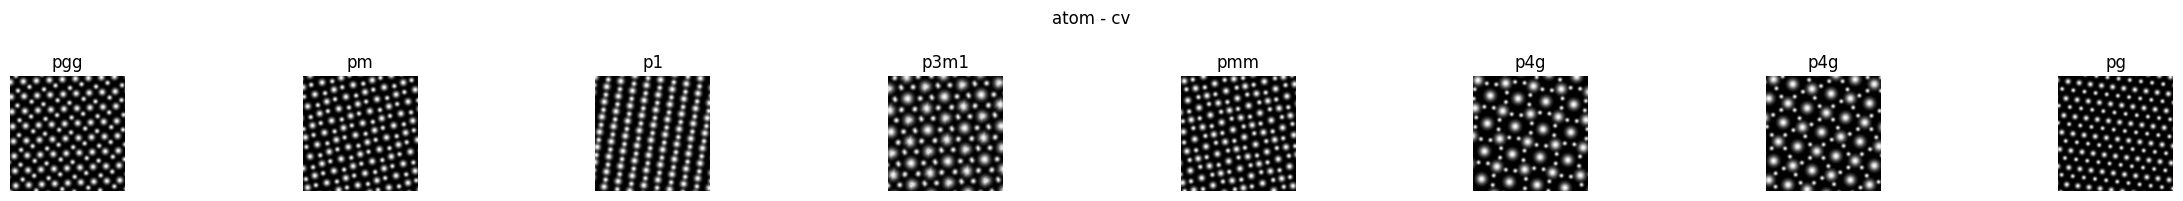

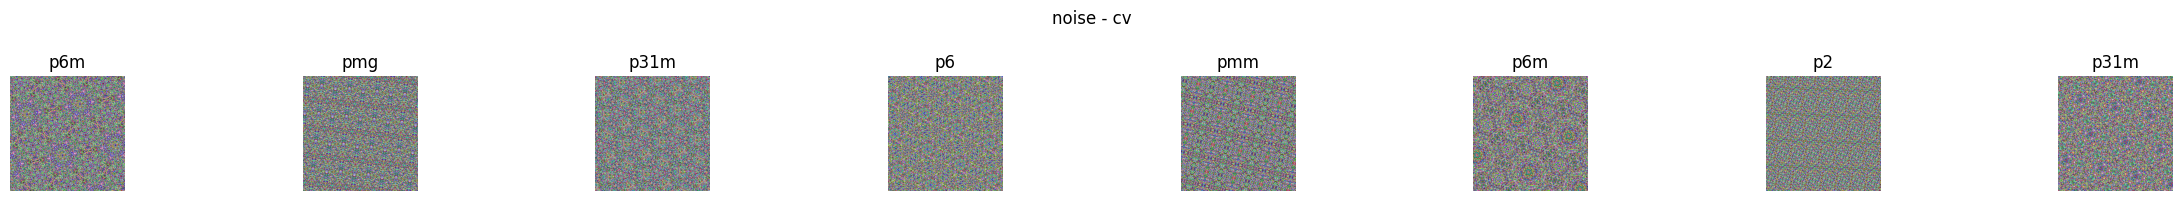

In [8]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)

# imagenet
imagenet_ds = hdf5_dataset('../../../datasets/imagenet_v5_rot_10m.h5', folder='train', transform=transforms.ToTensor())
train_ds, valid_ds = split_train_valid(imagenet_ds, 0.8)
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=4)
viz_dataloader(train_dl, label_converter=label_converter, title='imagenet - train')
valid_dl = DataLoader(valid_ds, batch_size=64, shuffle=False, num_workers=4)
viz_dataloader(valid_dl, label_converter=label_converter, title='imagenet - valid')

# atom
atom_ds = hdf5_dataset('../../../datasets/atom_v5_rot_200k.h5', folder='test', transform=transforms.ToTensor())
atom_dl = DataLoader(atom_ds, batch_size=64, shuffle=False, num_workers=4)
viz_dataloader(atom_dl, label_converter=label_converter, title='atom - cv')

# noise
noise_ds = hdf5_dataset('../../../datasets/imagenet_atom_noise_v4_rot_10m_100k_subset.h5', folder='noise', transform=transforms.ToTensor())
noise_dl = DataLoader(noise_ds, batch_size=800, shuffle=False, num_workers=4)
viz_dataloader(noise_dl, label_converter=label_converter, title='noise - cv')

In [4]:
model = resnet50_(in_channels=3, n_classes=17)
outputs = model(torch.randn(2,3,256,256))
print(outputs.shape)
model = torch.nn.DataParallel(model, device_ids=[1,3])
# model

torch.Size([2, 17])


In [5]:
config = {
    'dataset': '10 million datasets',
    'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
    'optimizer': 'Adam',
    'scheduler': 'OneCycleLR',
}

NAME = '05242024-benchmark-resnet50_from_scratch-v5_10m'

# train

In [6]:
wandb.login()
proj_name = 'Understanding-Experimental-Images-by-Identifying-Symmetries-with-Deep-Learning'
wandb.init(project=proj_name, entity='yig319', name=NAME, id=NAME, save_code=True, config=config)
config = wandb.config

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: yig319. Use `wandb login --relogin` to force relogin
